In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pennylane as qml
from tqdm import tqdm
import math

In [2]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 70.9 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 69.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 24.6 MB/s eta 0:00:0000:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 94.5 MB/s eta 0:00:00:00:0100:01


In [4]:
import os
import glob
import numpy as np
from typing import Tuple

import torch
from torch.utils.data import Dataset, DataLoader

class UAVHSICropDataset(Dataset):
    def __init__(self, root_dir: str, split: str = "Training"):
        """
        root_dir: path to 'uav-hsi/Train' or 'uav-hsi/Test'
        split: 'Training', 'Validation', or 'Test'
        """
        if split in ["Training", "Validation"]:
            base = os.path.join(root_dir, split)
        elif split == "Test":
            base = root_dir  # root_dir should be 'uav-hsi/Test'
        else:
            raise ValueError("split must be Training, Validation or Test")

        self.rs_dir = os.path.join(base, "rs")
        self.gt_dir = os.path.join(base, "gt")

        self.rs_files = sorted(glob.glob(os.path.join(self.rs_dir, "*.npy")))
        self.gt_files = sorted(glob.glob(os.path.join(self.gt_dir, "*.npy")))
        assert len(self.rs_files) == len(self.gt_files), "rs/gt count mismatch"

    def __len__(self):
        return len(self.rs_files)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        rs_path = self.rs_files[idx]
        gt_path = self.gt_files[idx]

        rs = np.load(rs_path)   # (H, W, C) = (96, 96, 200) assumed [web:7][web:19]
        gt = np.load(gt_path)   # (H, W) int mask

        # to tensor, channels-first
        rs = torch.from_numpy(rs).float().permute(2, 0, 1)  # (C, H, W)
        gt = torch.from_numpy(gt).long()                    # (H, W)

        return rs, gt

def make_loaders(root_train: str, root_test: str,
                 batch_size: int = 8, num_workers: int = 4):
    train_ds = UAVHSICropDataset(root_train, "Training")
    val_ds   = UAVHSICropDataset(root_train, "Validation")
    test_ds  = UAVHSICropDataset(root_test,  "Test")

    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True, num_workers=num_workers,
                              pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size,
                            shuffle=False, num_workers=num_workers,
                            pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size,
                             shuffle=False, num_workers=num_workers,
                             pin_memory=True)
    return train_loader, val_loader, test_loader

In [16]:
# ============================================================
# FIXED QUANTUM PATCHGRAPH TRANSFORMER (DROP-IN MODULE)
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import pennylane as qml
import math

# ============================================================
# QUANTUM PATCH CLASSIFIER (FIXED TORCHLAYER VERSION)
# ============================================================

class QuantumPatchHead(nn.Module):
    def __init__(self, embed_dim=192, num_classes=30, n_qubits=4):
        super().__init__()
        self.n_qubits = n_qubits

        # --- CRITICAL FIX: Feature reduction BEFORE quantum ---
        self.feature_reduce = nn.Sequential(
            nn.Linear(embed_dim, n_qubits * 2),
            nn.Tanh(),
            nn.Linear(n_qubits * 2, n_qubits)
        )

        # PennyLane device
        dev = qml.device("default.qubit", wires=n_qubits)

        @qml.qnode(dev, interface="torch")
        def quantum_circuit(inputs, weights):
            qml.AngleEmbedding(inputs, wires=range(n_qubits))
            qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
            return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

        weight_shapes = {"weights": (2, n_qubits)}
        self.qlayer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

        # Classical post-processing
        self.post_net = nn.Sequential(
            nn.Linear(n_qubits, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):  # x: (B, N, 192)
        B, N, _ = x.shape

        x_reduced = self.feature_reduce(x)          # (B, N, 4)
        x_q = self.qlayer(x_reduced.view(B * N, -1)) # (B*N, 4)
        x_q = x_q.view(B, N, -1)

        logits = self.post_net(x_q)                 # (B, N, C)
        return logits


# ============================================================
# PATCH EMBEDDING
# ============================================================

class PatchEmbed(nn.Module):
    def __init__(self, in_channels=200, patch_size=6, embed_dim=192, img_size=96):
        super().__init__()
        self.patch_size = patch_size
        self.grid_h = img_size // patch_size
        self.grid_w = img_size // patch_size
        self.num_patches = self.grid_h * self.grid_w

        self.proj = nn.Conv2d(
            in_channels, embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )
        self.pos_embed = nn.Parameter(
            torch.zeros(1, self.num_patches, embed_dim)
        )

    def forward(self, x):
        x = self.proj(x)
        B, D, Gh, Gw = x.shape
        x = x.flatten(2).transpose(1, 2)
        return x + self.pos_embed


# ============================================================
# GRID GRAPH CONSTRUCTION
# ============================================================

def make_grid_edges(grid_h, grid_w, device):
    N = grid_h * grid_w
    adj = torch.zeros(N, N, device=device)

    def idx(i, j):
        return i * grid_w + j

    for i in range(grid_h):
        for j in range(grid_w):
            u = idx(i, j)
            for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
                ni, nj = i + di, j + dj
                if 0 <= ni < grid_h and 0 <= nj < grid_w:
                    v = idx(ni, nj)
                    adj[u, v] = 1.0

    adj.fill_diagonal_(1.0)
    return adj


# ============================================================
# GRAPH ATTENTION
# ============================================================

class GraphAttention(nn.Module):
    def __init__(self, dim, num_heads=4, dropout=0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads

        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
        self.attn_drop = nn.Dropout(dropout)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x, adj):
        B, N, D = x.shape

        qkv = self.qkv(x).reshape(
            B, N, 3, self.num_heads, self.head_dim
        ).permute(2, 0, 3, 1, 4)

        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        mask = (adj == 0).unsqueeze(0).unsqueeze(0)
        attn = attn.masked_fill(mask, float("-inf"))

        attn = F.softmax(attn, dim=-1)
        attn = self.attn_drop(attn)

        out = attn @ v
        out = out.transpose(1, 2).reshape(B, N, D)
        out = self.proj(out)
        return self.proj_drop(out)


# ============================================================
# GRAPH TRANSFORMER BLOCK
# ============================================================

class GraphTransformerBlock(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = GraphAttention(dim, num_heads, dropout)

        self.norm2 = nn.LayerNorm(dim)
        hidden_dim = int(dim * mlp_ratio)

        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x, adj):
        x = x + self.attn(self.norm1(x), adj)
        x = x + self.mlp(self.norm2(x))
        return x


# ============================================================
# FINAL QUANTUM PATCHGRAPH TRANSFORMER
# ============================================================

class PatchGraphTransformerQuantum(nn.Module):
    def __init__(
        self,
        in_channels=200,
        num_classes=30,
        img_size=96,
        patch_size=6,
        embed_dim=192,
        depth=6,
        num_heads=4,
        mlp_ratio=4.0,
        dropout=0.1
    ):
        super().__init__()

        self.img_size = img_size
        self.patch_size = patch_size

        self.patch_embed = PatchEmbed(
            in_channels, patch_size, embed_dim, img_size
        )

        self.grid_h = img_size // patch_size
        self.grid_w = img_size // patch_size

        self.blocks = nn.ModuleList([
            GraphTransformerBlock(
                embed_dim, num_heads, mlp_ratio, dropout
            )
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(embed_dim)

        # --- Quantum classifier ---
        self.patch_classifier = QuantumPatchHead(
            embed_dim, num_classes
        )

    def forward(self, x):
        device = x.device
        adj = make_grid_edges(self.grid_h, self.grid_w, device)

        tokens = self.patch_embed(x)
        for blk in self.blocks:
            tokens = blk(tokens, adj)

        tokens = self.norm(tokens)

        patch_logits = self.patch_classifier(tokens)

        B, N, C = patch_logits.shape
        patch_logits = patch_logits.transpose(1, 2).reshape(
            B, C, self.grid_h, self.grid_w
        )

        logits = F.interpolate(
            patch_logits,
            size=(self.img_size, self.img_size),
            mode="bilinear",
            align_corners=False
        )
        return logits



Epoch 1


Eval: 100%|██████████| 5/5 [00:02<00:00,  2.41it/s]


Train loss: 3.3090 | Val loss: 3.2282 | Val OA: 10.17%
Saved best model.

Epoch 2


Eval: 100%|██████████| 5/5 [00:02<00:00,  2.43it/s]


Train loss: 3.0811 | Val loss: 3.0123 | Val OA: 10.17%
Saved best model.

Epoch 3


...

Eval: 100%|██████████| 5/5 [00:02<00:00,  2.25it/s]


Train loss: 0.8390 | Val loss: 1.0455 | Val OA: 69.18%


Eval: 100%|██████████| 11/11 [00:05<00:00,  1.98it/s]


Test loss: 1.0980 | Test OA: 72.28%

📊 Computing confusion matrix...


Confusion matrix: 100%|██████████| 11/11 [00:04<00:00,  2.47it/s]


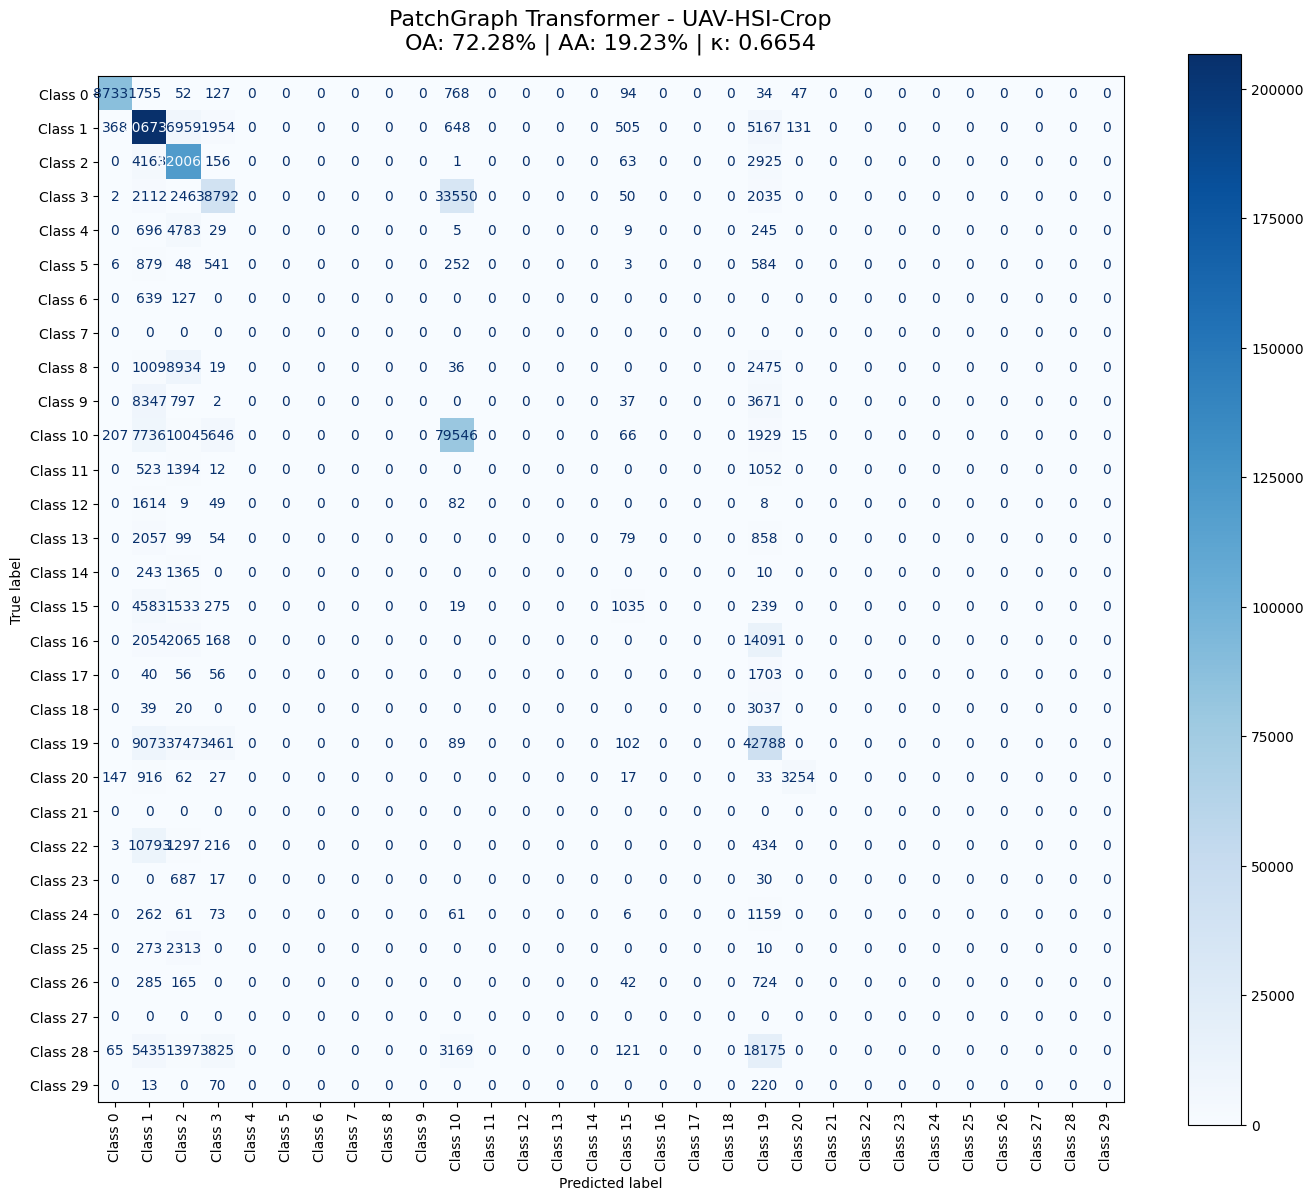


🎯 FINAL METRICS (HSI-TransUNet paper format):
Test OA:        72.28%
Test AA:        19.23%
Test Kappa:     0.6654
mIoU:           0.1530
Mean class acc: 0.1923
Min class acc:  0.0000
Max class acc:  0.9790


In [17]:
import torch
import torch.nn.functional as F
from torch.optim import AdamW
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    for rs, gt in tqdm(loader, desc="Train"):
        rs = rs.to(device, non_blocking=True)   # (B,C,H,W)
        gt = gt.to(device, non_blocking=True)   # (B,H,W)

        optimizer.zero_grad()
        logits = model(rs)                      # (B,C,H,W)
        loss = F.cross_entropy(logits, gt)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * rs.size(0)
    return total_loss / len(loader.dataset)


def eval_one_epoch(model, loader, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for rs, gt in tqdm(loader, desc="Eval"):
            rs = rs.to(device, non_blocking=True)
            gt = gt.to(device, non_blocking=True)

            logits = model(rs)
            loss = F.cross_entropy(logits, gt)
            total_loss += loss.item() * rs.size(0)

            preds = logits.argmax(dim=1)       # (B,H,W)
            correct += (preds == gt).sum().item()
            total += gt.numel()
    return total_loss / len(loader.dataset), correct / total


def compute_confusion_matrix(model, test_loader, device, num_classes=30):
    """Compute confusion matrix on test set"""
    model.eval()
    all_preds = []
    all_gts = []
    
    with torch.no_grad():
        for rs, gt in tqdm(test_loader, desc="Confusion matrix"):
            rs = rs.to(device, non_blocking=True)
            gt = gt.to(device, non_blocking=True)
            
            logits = model(rs)
            preds = logits.argmax(dim=1).cpu().numpy()  # (B,H,W)
            gts = gt.cpu().numpy()                      # (B,H,W)
            
            all_preds.extend(preds.ravel())
            all_gts.extend(gts.ravel())
    
    cm = confusion_matrix(all_gts, all_preds, labels=range(num_classes))
    return cm


def compute_aa_kappa(cm, num_classes=30):
    """Compute AA and Kappa from confusion matrix"""
    # Overall Accuracy (OA)
    oa = np.trace(cm) / np.sum(cm)
    
    # Average Accuracy (AA) - mean per-class accuracy
    per_class_acc = np.diag(cm) / (cm.sum(axis=1) + 1e-8)
    aa = np.mean(per_class_acc)
    
    # Kappa coefficient
    pe = np.sum(cm.sum(axis=1) * cm.sum(axis=0)) / (np.sum(cm) ** 2)
    kappa = (oa - pe) / (1 - pe + 1e-8)
    
    return oa, aa, kappa


def main():
    root_train = "/kaggle/input/uav-hsi/Train"
    root_test  = "/kaggle/input/uav-hsi/Test"

    train_loader, val_loader, test_loader = make_loaders(
        root_train, root_test,
        batch_size=8, num_workers=4
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = PatchGraphTransformerQuantum(
        in_channels=200, num_classes=30,
        img_size=96, patch_size=6,
        embed_dim=192, depth=6, num_heads=4,
        mlp_ratio=4.0, dropout=0.1
    ).to(device)

    optimizer = AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

    best_val = float("inf")
    for epoch in range(1, 101):
        print(f"\nEpoch {epoch}")
        train_loss = train_one_epoch(model, train_loader, optimizer, device)
        val_loss, val_oa = eval_one_epoch(model, val_loader, device)
        print(f"Train loss: {train_loss:.4f} | "
              f"Val loss: {val_loss:.4f} | "
              f"Val OA: {val_oa*100:.2f}%")

        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), "patchgraph_uavhsi_best.pth")
            print("Saved best model.")

    # final test
    model.load_state_dict(torch.load("patchgraph_uavhsi_best.pth",
                                     map_location=device))
    test_loss, test_oa = eval_one_epoch(model, test_loader, device)
    print(f"Test loss: {test_loss:.4f} | Test OA: {test_oa*100:.2f}%")
    
    # === CONFUSION MATRIX + FULL METRICS ===
    print("\n📊 Computing confusion matrix...")
    cm = compute_confusion_matrix(model, test_loader, device)
    
    # Compute OA, AA, Kappa (exactly matching HSI-TransUNet paper format)
    test_oa_full, test_aa, test_kappa = compute_aa_kappa(cm)
    
    # Plot confusion matrix
    fig, ax = plt.subplots(figsize=(14, 12))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                display_labels=[f"Class {i}" for i in range(30)])
    disp.plot(ax=ax, cmap=plt.cm.Blues, values_format='d', xticks_rotation=90)
    plt.title(f'PatchGraph Transformer - UAV-HSI-Crop\n'
              f'OA: {test_oa_full*100:.2f}% | AA: {test_aa*100:.2f}% | '
              f'κ: {test_kappa:.4f}', fontsize=16, pad=20)
    plt.tight_layout()
    plt.savefig('patchgraph_confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Key metrics (HSI-TransUNet paper format)
    per_class_acc = np.diag(cm).astype(float) / (cm.sum(axis=1) + 1e-8)
    miou = np.mean(np.diag(cm) / (cm.sum(axis=1) + cm.sum(axis=0) - np.diag(cm) + 1e-8))
    
    print(f"\n🎯 FINAL METRICS (HSI-TransUNet paper format):")
    print(f"Test OA:        {test_oa_full*100:.2f}%")
    print(f"Test AA:        {test_aa*100:.2f}%")
    print(f"Test Kappa:     {test_kappa:.4f}")
    print(f"mIoU:           {miou:.4f}")
    print(f"Mean class acc: {per_class_acc.mean():.4f}")
    print(f"Min class acc:  {per_class_acc.min():.4f}")
    print(f"Max class acc:  {per_class_acc.max():.4f}")

if __name__ == "__main__":
    main()